# Figure 3 Jupyter Notebook

## Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.ticker as tck
import glob
import os

from lmfit import Model

## Subfigure (a): Photon Pair Storage

In [4]:
FILENAME = ('/Users/alexkolar/Library/CloudStorage/Box-Box/Zhonglab/Lab data/Ring Resonators'
            '/Mounted_device_mk_5/10mK/2026_03_30/afc_longterm/afc_storage_experiment.npz')
FILENAME_OFFRES = ('/Users/alexkolar/Library/CloudStorage/Box-Box/Zhonglab/Lab data/Ring Resonators'
                   '/Mounted_device_mk_5/10mK/2026_03_31/afc_longterm/afc_storage_experiment.npz')

data_pairs = np.load(FILENAME)
data_pairs_offres = np.load(FILENAME_OFFRES)
coincidence = data_pairs["counts"]
coincidence_offres = data_pairs_offres["counts"]
time = data_pairs["bins"]

center = time[np.argmax(coincidence)]
time -= center

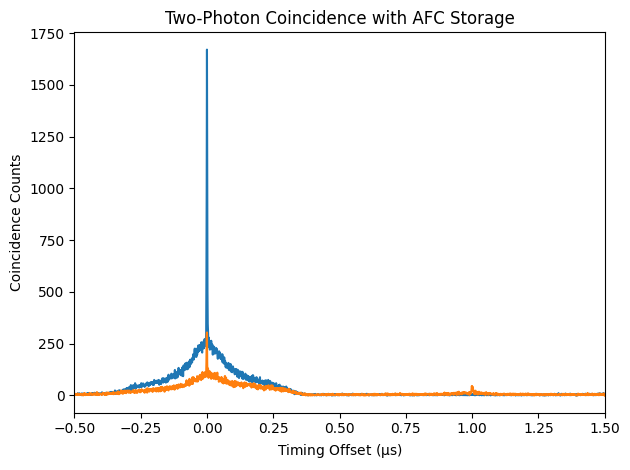

In [5]:
xlim = -0.5, 1.5

plt.plot(time, coincidence_offres)
plt.plot(time, coincidence)
plt.xlim(xlim)
plt.xlabel(r"Timing Offset ($\mathrm{\mu}$s)")
plt.ylabel("Coincidence Counts")
plt.title("Two-Photon Coincidence with AFC Storage")
plt.tight_layout()

Also define inset for echo counts

/var/folders/9s/1vly09jx3z36sfxgrw8bfrf80000gn/T/ipykernel_69550/2475491222.py:14: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


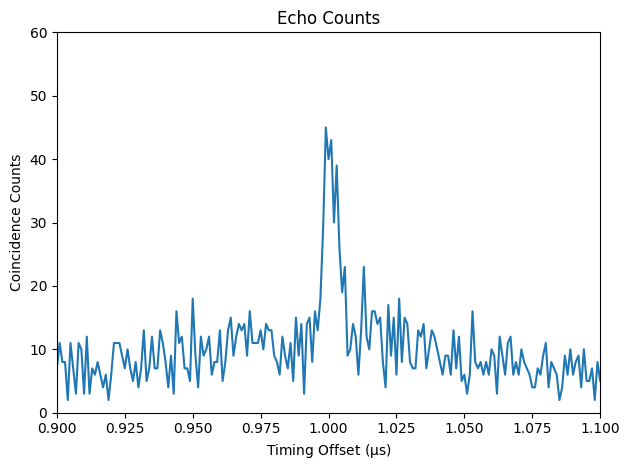

In [6]:
xlim_echo = 0.9, 1.1
ylim_echo = 0, 60

fig, ax = plt.subplots()

ax.plot(time, coincidence)
ax.set_xlim(xlim_echo)
ax.set_ylim(ylim_echo)
ax.set_xlabel(r"Timing Offset ($\mathrm{\mu}$s)")
ax.set_ylabel("Coincidence Counts")
ax.set_title("Echo Counts")

fig.tight_layout()
fig.show()

## Subfigure (b): Coincidence Interference

In [7]:
DATA_CONSTRUCTIVE = ('/Users/alexkolar/Library/CloudStorage/Box-Box/Zhonglab/Lab data/Ring Resonators'
                     '/Unmounted_device_mk_3/2026_04_15/pair_generation/interference_350mV_negP_5min.txt')
DATA_DESTRUCTIVE = ('/Users/alexkolar/Library/CloudStorage/Box-Box/Zhonglab/Lab data/Ring Resonators'
                    '/Unmounted_device_mk_3/2026_04_15/pair_generation/interference_210mV_5min.txt')
num_bins = 60

df_constructive = pd.read_csv(DATA_CONSTRUCTIVE, sep='\t')
df_destructive = pd.read_csv(DATA_DESTRUCTIVE, sep='\t')

time_interference = df_constructive['Time(ps)']
time_interference *= 1e-3  # convert to ns

center_bin = np.argmax(df_constructive['Counts'])
idx_start = center_bin - num_bins // 2
idx_end = center_bin + num_bins // 2 + 1

counts_constructive = np.sum(df_constructive['Counts'][idx_start:idx_end])
counts_destructive = np.sum(df_destructive['Counts'][idx_start:idx_end])
visibility = (counts_constructive - counts_destructive) / (counts_constructive + counts_destructive)
print(f'Visibility: {visibility*100:.2f}%')

Visibility: 83.21%


6.2047727272727276
4.990454545454545
0.9626952574957804


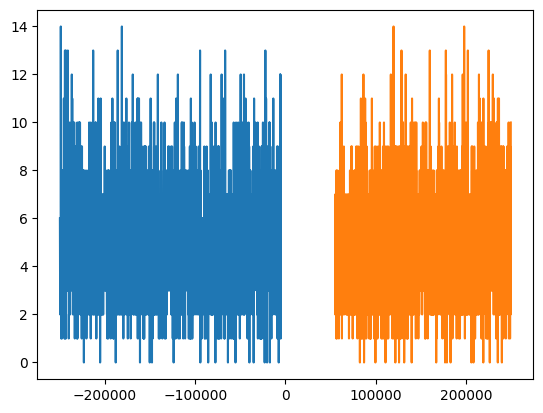

In [8]:
idx_bg_end1 = center_bin-300
idx_bg_start2 = center_bin+300
plt.figure()
plt.plot(df_destructive['Time(ps)'][0:idx_bg_end1],df_destructive['Counts'][0:idx_bg_end1])
plt.plot(df_destructive['Time(ps)'][idx_bg_start2:],df_destructive['Counts'][idx_bg_start2:])

bg_constructive = np.mean(np.concatenate((df_constructive['Counts'][0:idx_bg_end1],df_constructive['Counts'][idx_bg_start2:]),axis=0))
bg_destructive = np.mean(np.concatenate((df_destructive['Counts'][0:idx_bg_end1],df_destructive['Counts'][idx_bg_start2:]),axis=0))
print(bg_constructive)
print(bg_destructive)

counts_constructive_no_bg = counts_constructive - (idx_end-idx_start)*bg_constructive
counts_destructive_no_bg = counts_destructive - (idx_end-idx_start)*bg_destructive

visibility_no_bg = (counts_constructive_no_bg-counts_destructive_no_bg)/(counts_constructive_no_bg+counts_destructive_no_bg)
print(visibility_no_bg)

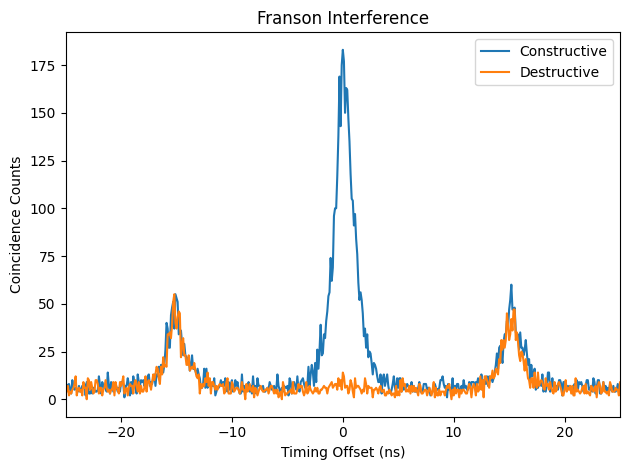

In [9]:
center_time_interference = time_interference[center_bin]

plt.plot(time_interference-center_time_interference, df_constructive['Counts'],
         label='Constructive')
plt.plot(time_interference-center_time_interference, df_destructive['Counts'],
         label='Destructive')
plt.title('Franson Interference')
plt.xlabel('Timing Offset (ns)')
plt.ylabel('Coincidence Counts')
plt.legend()
plt.xlim((-25, 25))
plt.tight_layout()

In [10]:
count_diff = (counts_constructive_no_bg-counts_destructive_no_bg)
count_sum = (counts_constructive_no_bg+counts_destructive_no_bg)
combined_std = np.sqrt(counts_constructive+counts_destructive)
visibility_err = visibility*np.sqrt(((combined_std) / count_diff)**2 + ((combined_std) / count_sum)**2)
print(f'Visibility error: {visibility_err*100:.2f}%')

Visibility error: 2.12%


In [11]:
count_diff = (counts_constructive_no_bg-counts_destructive_no_bg)
count_sum = (counts_constructive_no_bg+counts_destructive_no_bg)
# calculate noise
noise_std = np.std(np.concatenate((df_constructive['Counts'][0:idx_bg_end1],df_constructive['Counts'][idx_bg_start2:]),axis=0))
print(f'Noise standard deviation: {noise_std:.2f}')
destructive_std = np.sqrt((idx_end-idx_start) * (noise_std**2)+counts_destructive_no_bg)
constructive_std = np.sqrt(((idx_end-idx_start) * (noise_std**2)) + counts_constructive_no_bg)
combined_std = np.sqrt(constructive_std**2 + destructive_std**2)
print(combined_std)
# visibility_err = visibility * np.sqrt(((np.sqrt(2) * combined_std) / count_diff)**2 + ((np.sqrt(2) * combined_std) / count_sum)**2)
visibility_err = visibility_no_bg * np.sqrt(((combined_std) / count_diff)**2 + ((combined_std) / count_sum)**2)
print(f'Visibility error: {visibility_err*100:.2f}%')
print(count_diff)


Noise standard deviation: 2.45
67.19124329491551
Visibility error: 2.46%
3642.926590909091


## Subfigure (c): Pair Storage Interference

In [14]:
DIRS_CONSTRUCTIVE = [('/Users/alexkolar/Library/CloudStorage/Box-Box/Zhonglab/Lab data/Ring Resonators/Mounted_device_mk_5/10mK/2026_03_23/afc_longterm'),
                     ('/Users/alexkolar/Library/CloudStorage/Box-Box/Zhonglab/Lab data/Ring Resonators/Mounted_device_mk_5/10mK/2026_03_26/afc_longterm'),
                     ('/Users/alexkolar/Library/CloudStorage/Box-Box/Zhonglab/Lab data/Ring Resonators/Mounted_device_mk_5/10mK/2026_03_27/afc_longterm')]
FILES_TO_INCLUDE_CONSTRUCTIVE = [12, 6, 2]
DIRS_DESTRUCTIVE = [('/Users/alexkolar/Library/CloudStorage/Box-Box/Zhonglab/Lab data/Ring Resonators/Mounted_device_mk_5/10mK/2026_03_21/afc_longterm'),
                    ('/Users/alexkolar/Library/CloudStorage/Box-Box/Zhonglab/Lab data/Ring Resonators/Mounted_device_mk_5/10mK/2026_03_25/afc_longterm')]
FILES_TO_INCLUDE_DESTRUCTIVE = [12, 15]

# plotting params
xlim_input = (-0.1, 0.1)
xlim_echo = (0.9, 1.1)
ylim_input = (0, 1200)
ylim_echo = (0, 150)


def sort_func(filename):
    file_parts = filename.split('_')
    try:
        return int(file_parts[-1].split('.')[0])
    except ValueError:
        return 0


all_counts_constructive = []
all_bins_constructive = []
for num_files, dir in zip(FILES_TO_INCLUDE_CONSTRUCTIVE, DIRS_CONSTRUCTIVE):
    all_files = glob.glob(os.path.join(dir, '*.npz'))
    all_files.sort(key=sort_func)

    # load data and plot individual files (constructive)
    all_bins = []
    all_counts = []
    all_freqs = []
    all_file_numbers = []
    for file in all_files:
        file_number = sort_func(file)
        all_file_numbers.append(file_number)

        data = np.load(file)
        counts = data['counts']
        bins = data['bins']
        freqs_start = data['freq_start']
        freqs_end = data['freq_end']
        all_counts.append(counts)
        all_bins.append(bins)
        all_freqs.append((freqs_start, freqs_end))

    all_counts_constructive += all_counts[:num_files]
    all_bins_constructive += all_bins[:num_files]


all_counts_destructive = []
all_bins_destructive = []
for num_files, dir in zip(FILES_TO_INCLUDE_DESTRUCTIVE, DIRS_DESTRUCTIVE):
    all_files = glob.glob(os.path.join(dir, '*.npz'))
    all_files.sort(key=sort_func)

    # load data and plot individual files (constructive)
    all_bins = []
    all_counts = []
    all_freqs = []
    all_file_numbers = []
    for file in all_files:
        file_number = sort_func(file)
        all_file_numbers.append(file_number)

        data = np.load(file)
        counts = data['counts']
        bins = data['bins']
        freqs_start = data['freq_start']
        freqs_end = data['freq_end']
        all_counts.append(counts)
        all_bins.append(bins)
        all_freqs.append((freqs_start, freqs_end))

    all_counts_destructive += all_counts[:num_files]
    all_bins_destructive += all_bins[:num_files]

# display number of files
print('Number of Constructive Files: ', len(all_counts_constructive))
print('Number of Destructive Files: ', len(all_counts_destructive))

# find center using constructive interference
bins = all_bins_constructive[0]
center = bins[np.argmax(all_counts_constructive[0])]
bins -= center

all_hist_constructive = np.sum(all_counts_constructive, axis=0)
all_hist_destructive = np.sum(all_counts_destructive, axis=0)

Number of Constructive Files:  20
Number of Destructive Files:  27


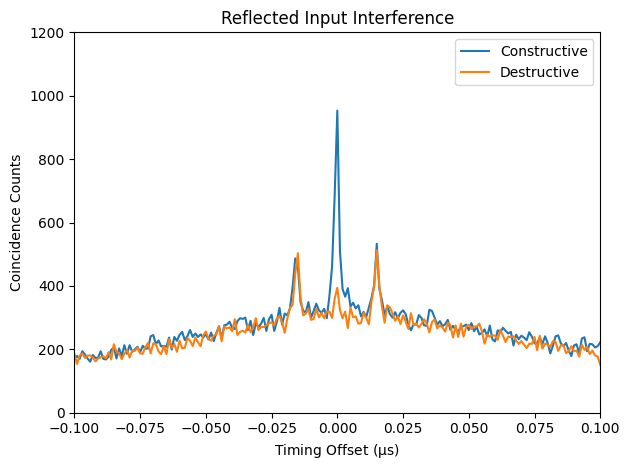

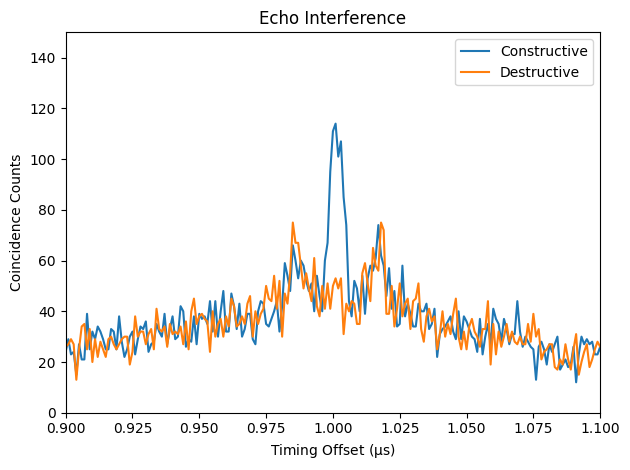

In [15]:
# plot just input
plt.plot(bins, all_hist_constructive, label='Constructive')
plt.plot(bins, all_hist_destructive, label='Destructive')
plt.xlim(xlim_input)
plt.ylim(ylim_input)
plt.xlabel(r'Timing Offset ($\mathrm{\mu}$s)')
plt.ylabel('Coincidence Counts')
plt.title('Reflected Input Interference')
plt.legend()
plt.tight_layout()
plt.show()

# plot just echo
plt.plot(bins, all_hist_constructive, label='Constructive')
plt.plot(bins, all_hist_destructive, label='Destructive')
plt.xlim(xlim_echo)
plt.ylim(ylim_echo)
plt.ylim(ylim_echo)
plt.xlabel(r'Timing Offset ($\mathrm{\mu}$s)')
plt.ylabel('Coincidence Counts')
plt.title('Echo Interference')
plt.legend()
plt.tight_layout()
plt.show()

[[Model]]
    Model(triangle_bg)
[[Fit Statistics]]
    # fitting method   = leastsq
    # function evals   = 34
    # data points      = 301
    # variables        = 3
    chi-square         = 9844.40105
    reduced chi-square = 33.0349028
    Akaike info crit   = 1055.75191
    Bayesian info crit = 1066.87324
    R-squared          = 0.63576678
[[Variables]]
    t0:     -1.00164488 +/- 0.00190607 (0.19%) (init = -1)
    slope:   173.851111 +/- 7.62434034 (4.39%) (init = 1)
    height:  43.6918201 +/- 0.66251745 (1.52%) (init = 40)
[[Correlations]] (unreported correlations are < 0.100)
    C(slope, height) = +0.8660
[[Model]]
    Model(triangle_bg)
[[Fit Statistics]]
    # fitting method   = leastsq
    # function evals   = 34
    # data points      = 301
    # variables        = 3
    chi-square         = 9364.23629
    reduced chi-square = 31.4236117
    Akaike info crit   = 1040.70038
    Bayesian info crit = 1051.82171
    R-squared          = 0.63868961
[[Variables]]
    t0:     

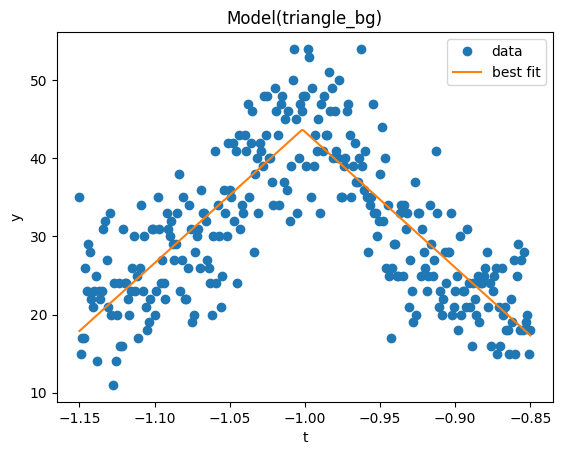

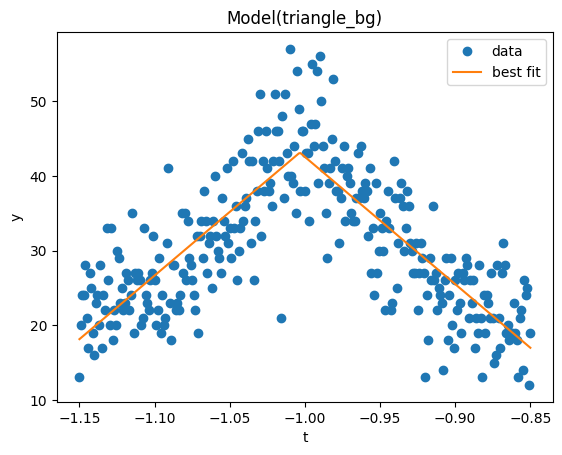

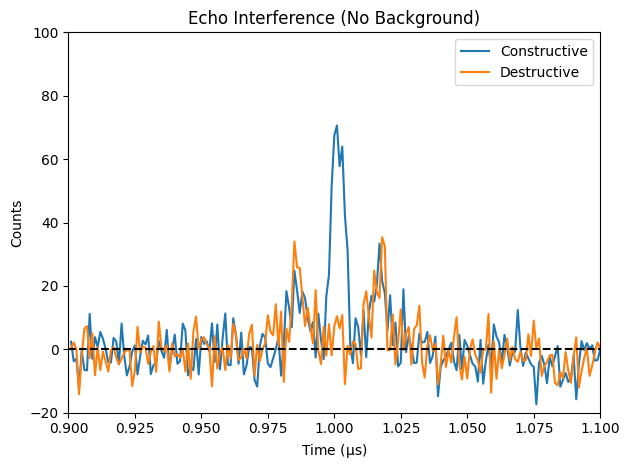

In [34]:
from lmfit import Model

def triangle_bg(t,t0,slope,height):
    return height-np.abs(slope*(t-t0))

bg_range_wide = (-1.15, -0.85)

bg_idx_wide = np.where((bins >= bg_range_wide[0]) & (bins <= bg_range_wide[1]))[0]

bg_model = Model(triangle_bg)
res_bg_con = bg_model.fit(all_hist_constructive[bg_idx_wide],t=bins[bg_idx_wide],t0=-1.,slope=1.,height=40)
plt.figure()
res_bg_con.plot_fit()
print(res_bg_con.fit_report())
res_bg_de = bg_model.fit(all_hist_destructive[bg_idx_wide],t=bins[bg_idx_wide],t0=-1.,slope=1.,height=40)
plt.figure()
res_bg_de.plot_fit()
print(res_bg_de.fit_report())


bg_range = (-1.1, -0.9)
window_range = (0.9985, 1.004)
bg_noise_range_1 = (1.025, 1.1)
bg_noise_range_2 = (0.9, 0.975)
# calculate visibility and error
# background subtraction
bg_idx = np.where((bins >= bg_range[0]) & (bins <= bg_range[1]))[0]
echo_idx = np.where((bins >= xlim_echo[0]) & (bins <= xlim_echo[1]))[0]
bins_echo = bins[echo_idx]
print(bins_echo)
echo_constructive_no_bg = all_hist_constructive[echo_idx]-triangle_bg(bins[bg_idx],res_bg_con.params['t0'].value,res_bg_con.params['slope'].value,res_bg_con.params['height'].value)#all_hist_constructive[echo_idx] - all_hist_constructive[bg_idx]
echo_destructive_no_bg = all_hist_destructive[echo_idx] - triangle_bg(bins[bg_idx],res_bg_de.params['t0'].value,res_bg_de.params['slope'].value,res_bg_de.params['height'].value)#all_hist_destructive[bg_idx]
echo_constructive_bg = all_hist_constructive[echo_idx]
echo_destructive_bg = all_hist_destructive[echo_idx]

# calculate visibility
window_idx = np.where((bins_echo >= window_range[0]) & (bins_echo <= window_range[1]))[0]
print('Time bins considered for visibility:', bins_echo[window_idx])
constructive_counts = np.sum(echo_constructive_no_bg[window_idx], axis=0)
destructive_counts = np.sum(echo_destructive_no_bg[window_idx], axis=0)
count_sum = constructive_counts + destructive_counts
count_diff = constructive_counts - destructive_counts
visibility = (constructive_counts - destructive_counts) / (constructive_counts + destructive_counts)
print('Constructive counts (no bg):', constructive_counts)
print('Destructive counts (no bg):', destructive_counts)
print(f'Visibility: {visibility*100:.2f}%')
constructive_counts_bg = np.sum(echo_constructive_bg[window_idx], axis=0)
destructive_counts_bg = np.sum(echo_destructive_bg[window_idx], axis=0)
visibility_bg = (constructive_counts_bg - destructive_counts_bg) / (constructive_counts_bg + destructive_counts_bg)
print('Constructive counts (bg):', constructive_counts_bg)
print('Destructive counts (bg):', destructive_counts_bg)
print(f'Visibility (bg): {visibility_bg*100:.2f}%')

# calculate noise
#noise_idx_1 = np.where((bins_echo >= bg_noise_range_1[0]) & (bins_echo <= bg_noise_range_1[1]))[0]
#noise_idx_2 = np.where((bins_echo >= bg_noise_range_2[0]) & (bins_echo <= bg_noise_range_2[1]))[0]
#total_noise_idx = np.concatenate((noise_idx_1, noise_idx_2))

bin_bg_var_con = np.square(res_bg_con.params['height'].stderr) + np.square((bins[bg_idx] - res_bg_con.params['t0'].value) * res_bg_con.params['slope'].value) * (np.square(res_bg_con.params['t0'].stderr/(bins[bg_idx] - res_bg_con.params['t0'].value)) + np.square(res_bg_con.params['slope'].stderr/res_bg_con.params['slope'].value))
bin_bg_var_de = np.square(res_bg_de.params['height'].stderr) + np.square((bins[bg_idx] - res_bg_de.params['t0'].value) * res_bg_de.params['slope'].value) * (np.square(res_bg_de.params['t0'].stderr/(bins[bg_idx] - res_bg_de.params['t0'].value)) + np.square(res_bg_de.params['slope'].stderr/res_bg_de.params['slope'].value))
print('total bg bins:', len(bin_bg_var_con))

noise_std_con = np.sqrt(np.sum(bin_bg_var_con[window_idx]))
# np.std(echo_destructive_no_bg[total_noise_idx])
noise_std_de = np.sqrt(np.sum(bin_bg_var_de[window_idx]))
print(f'BG subtraction std (constructive): {noise_std_con:.2f}')
print(f'BG subtraction std (destructive): {noise_std_de:.2f}')
# destructive_std = noise_std_de  # np.sqrt(len(window_idx)) * noise_std
# constructive_std = np.sqrt(noise_std_con + constructive_counts)
destructive_std = np.sqrt(destructive_counts_bg + np.square(noise_std_de))
constructive_std = np.sqrt(constructive_counts_bg + np.square(noise_std_con))
combined_std = np.sqrt(constructive_std**2 + destructive_std**2)
# visibility_err = visibility * np.sqrt(((np.sqrt(2) * combined_std) / count_diff)**2 + ((np.sqrt(2) * combined_std) / count_sum)**2)
visibility_err = visibility * np.sqrt((combined_std / count_diff)**2 + (combined_std / count_sum)**2)
print(f'Visibility error: {visibility_err*100:.2f}%')

# plotting of background subtraction
plt.figure()
plt.plot(bins[echo_idx], echo_constructive_no_bg, label='Constructive')
plt.plot(bins[echo_idx], echo_destructive_no_bg, label='Destructive')
plt.axhline(0, ls='--', color='k')
plt.xlim(xlim_echo)
plt.ylim(-20, 100)
plt.xlabel(r'Time ($\mathrm{\mu}$s)')
plt.ylabel('Counts')
plt.title('Echo Interference (No Background)')
plt.legend()
plt.tight_layout()
plt.show()

# Main Plot Code

First, define plotting parameters

In [13]:
# matplotlib general (and font)
mpl.rcParams.update({'font.sans-serif': 'Arial',
                     'font.size': 7})
figwidth_mm = 180
figsize = (figwidth_mm/25.4, 2)  # inches
dpi = 300
include_subplot_titles = False

# colors
color_constructive = '#a6cee3'
color_destructive = '#1f78b4'
color_primary = color_constructive
color_secondary = color_destructive

# figure layout
horizontal_ratios = (1.5, 1, 1)
vertical_padding = 0.05
horizontal_padding = 0.05

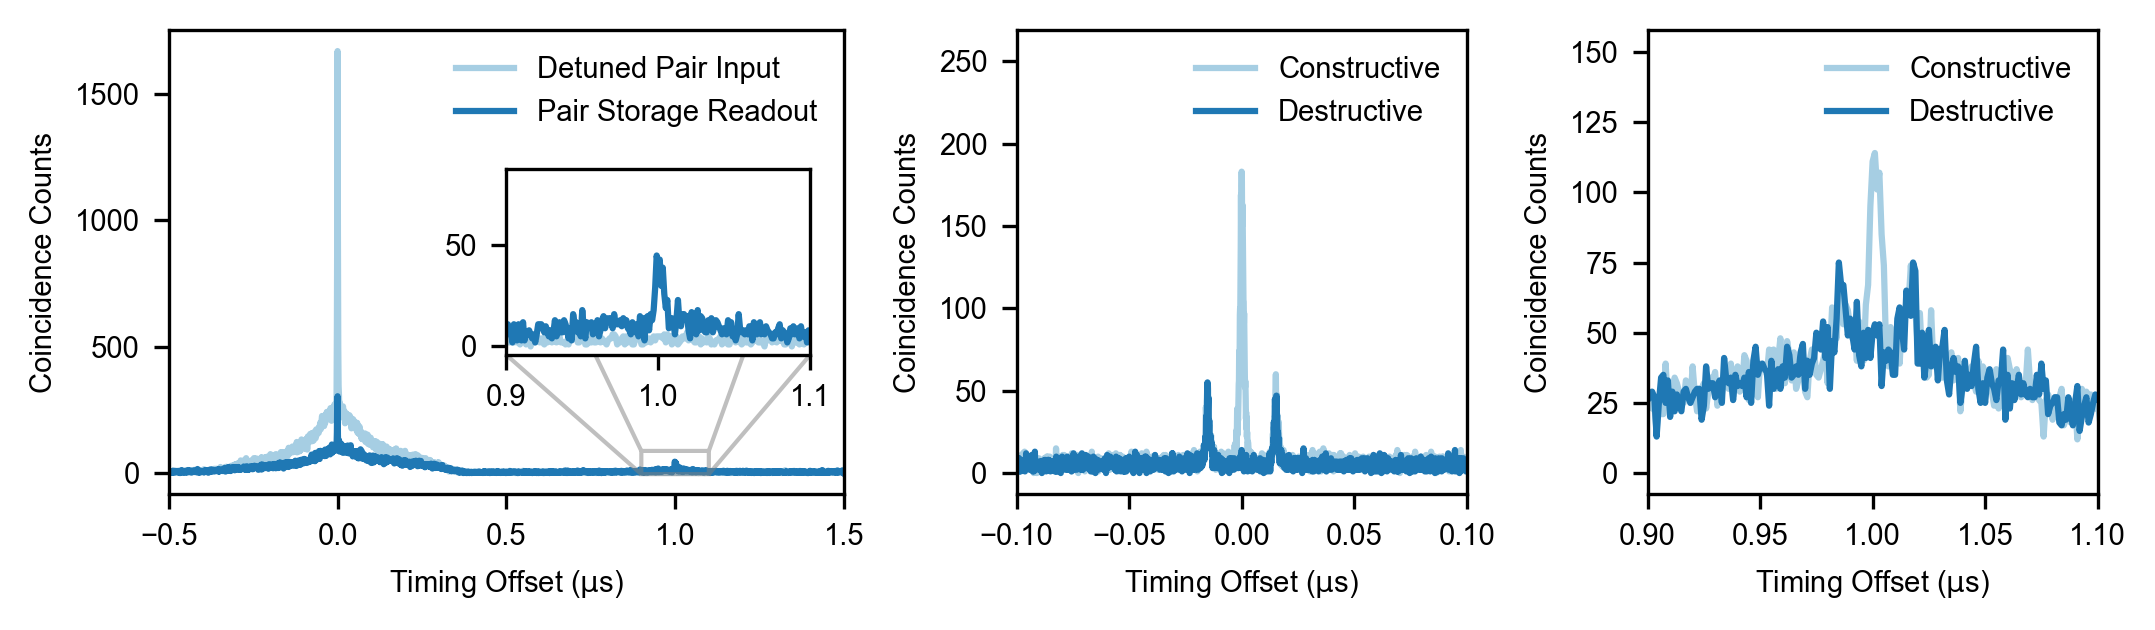

In [14]:
fig = plt.figure(layout='constrained', figsize=figsize, dpi=dpi)
fig.get_layout_engine().set(w_pad=horizontal_padding, h_pad=vertical_padding)
axs = fig.subplots(1, 3, width_ratios=horizontal_ratios)

xlim_pair = -0.5, 1.5
xlim_pair_echo = 0.9, 1.1
axs[0].plot(time, coincidence_offres,
            color=color_primary, label='Detuned Pair Input')
axs[0].plot(time, coincidence,
            color=color_secondary, label='Pair Storage Readout')
axs[0].set_xlabel(r'Timing Offset ($\mathrm{\mu}$s)')
axs[0].set_ylabel("Coincidence Counts")
axs[0].set_xlim(xlim_pair)
axs[0].legend(frameon=False)
axs_0_ylim = axs[0].get_ylim()
echo_scaling_factor = 0.05  # approximately equal to efficiency
ylim_pair_echo = tuple(y * 0.05 for y in axs_0_ylim)
axs_0_inset = axs[0].inset_axes([0.5, 0.3, 0.45, 0.4],
                                xlim=xlim_pair_echo, ylim=ylim_pair_echo,)
axs_0_inset.plot(time, coincidence_offres, color=color_primary)
axs_0_inset.plot(time, coincidence, color=color_secondary)
axs[0].indicate_inset_zoom(axs_0_inset)

xlim_pair_interference = (-0.1, 0.1)
axs[1].plot((time_interference-center_time_interference)/1e3, df_constructive['Counts'],
            color=color_constructive, label='Constructive')
axs[1].plot((time_interference-center_time_interference)/1e3, df_destructive['Counts'],
            color=color_destructive, label='Destructive')
axs[1].set_xlabel(r'Timing Offset ($\mathrm{\mu}$s)')
axs[1].set_ylabel('Coincidence Counts')
axs[1].set_xlim(xlim_pair_interference)
axs[1].legend(frameon=False)
old_ylim = axs[1].get_ylim()
factor = 1.4
axs[1].set_ylim((old_ylim[0]*factor, old_ylim[1]*factor))

axs_2_ylim = tuple(y * 0.09 for y in axs_0_ylim)
axs[2].plot(bins, all_hist_constructive,
            color=color_constructive, label='Constructive')
axs[2].plot(bins, all_hist_destructive,
            color=color_destructive, label='Destructive')
axs[2].set_xlim(xlim_echo)
axs[2].set_ylim(axs_2_ylim)
axs[2].set_xlabel(r'Timing Offset ($\mathrm{\mu}$s)')
axs[2].set_ylabel('Coincidence Counts')
axs[2].legend(frameon=False)

In [15]:
fig.savefig('fig3.pdf')